# AX-CPT 12-Year Preprocessing Pipeline

## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

TRIAL_TYPES = ["AX", "AY", "BX", "BY"]
COLORS = {"AX": "#4C72B0", "AY": "#DD8452", "BX": "#55A868", "BY": "#C44E52"}

## Load data

In [18]:
# notebook is in .../notebooks/, so parent is project root
project_root = Path.cwd().parent
data_path = project_root / "data" / "AXCPT_For_Server.sav"

print("Project root:", project_root)
print("Data path:", data_path)
print("Exists:", data_path.exists())

df, meta = pyreadstat.read_sav(data_path)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head(3)

Project root: /Users/yizj/Desktop/AX-CPT/metaControl_behavioral_Inhibition
Data path: /Users/yizj/Desktop/AX-CPT/metaControl_behavioral_Inhibition/data/AXCPT_For_Server.sav
Exists: True
Rows: 316, Columns: 37


,ID,Completed_AX_CPT_12yr,acc_rej_12yr,AX_CPT_Notes_12yr,Mean_RT_12yr,Std_pop_12yr,Std_3_12yr,Lo_Std_12yr,Hi_Std_12yr,AX_Count_12yr,...,AY_Acc_12yr,BX_Acc_12yr,BY_Acc_12yr,PBSI_ErrorRate_12yr,PBSI_RT_12yr,PBSI_SUM_12yr,dprime_context_12yr,A_Cue_Bias_12yr,A_Cue_Bias_Check,AY_False_Alarm
0,6015.0,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6018.0,1.0,1.0,,450.33,127.57,382.71,67.62,833.04,105.0,...,0.357143,0.571429,0.928571,0.1875,0.174679,0.362179,0.498652,0.342373,0.342373,0.642857
2,6021.0,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Define column groups

In [3]:
count_cols = [f"{t}_Count_Filtered_12yr" for t in TRIAL_TYPES]
acc_count_cols = [f"{t}_Acc_Count_12yr" for t in TRIAL_TYPES]
acc_rate_cols = [f"{t}_Acc_12yr" for t in TRIAL_TYPES]
rt_cols = [f"{t}_RT_12yr" for t in TRIAL_TYPES]
core_cols = count_cols + acc_count_cols

label_of = {f"{t}_Count_Filtered_12yr": t for t in TRIAL_TYPES}
label_of.update({f"{t}_Acc_12yr": t for t in TRIAL_TYPES})

## Missingness audit

Each participant needs all four filtered counts **and** all four correct counts
to reconstruct the binomial cells (successes / trials). Flag completeness accordingly.

In [4]:
df["has_all_counts"] = df[count_cols].notna().all(axis=1)
df["has_all_acc_counts"] = df[acc_count_cols].notna().all(axis=1)
df["model_usable"] = df[core_cols].notna().all(axis=1)
df["has_any_core"] = df[core_cols].notna().any(axis=1)

summary = pd.DataFrame({
    "N": [
        len(df),
        df["has_any_core"].sum(),
        df["has_all_counts"].sum(),
        df["has_all_acc_counts"].sum(),
        df["model_usable"].sum(),
    ]
}, index=["Total rows", "Any core data", "All 4 counts", "All 4 acc counts", "Model-usable (complete)"])
summary

,N
Total rows,316
Any core data,139
All 4 counts,139
All 4 acc counts,139
Model-usable (complete),139


### QC and completion flags

In [5]:
print("QC flag (acc_rej_12yr):")
print(df["acc_rej_12yr"].value_counts(dropna=False).sort_index())
print()
print("Completion flag:")
print(df["Completed_AX_CPT_12yr"].value_counts(dropna=False).sort_index())
print()
print("QC × model-usable cross-tab:")
pd.crosstab(df["acc_rej_12yr"], df["model_usable"], margins=True, dropna=False)

QC flag (acc_rej_12yr):
acc_rej_12yr
1.0    130
9.0     11
NaN    175
Name: count, dtype: int64

Completion flag:
Completed_AX_CPT_12yr
1.0    134
9.0      7
NaN    175
Name: count, dtype: int64

QC × model-usable cross-tab:


model_usable,False,True,All
acc_rej_12yr,,,
1.0,0,130,130.0
9.0,2,9,11.0
NaN,175,0,NaN
All,177,139,316.0


## Build usable subset

In [6]:
usable = df[df["model_usable"]].copy()
print(f"Usable N = {len(usable)}")

Usable N = 139


### Low-count audit

Cells with very few trials inflate variance of the binomial proportion
and can dominate likelihood. Flag counts < 5.

In [17]:
low_count = pd.DataFrame({
    "zero": (usable[count_cols] == 0).sum(),
    "< 5":  (usable[count_cols] < 5).sum(),
    "< 10": (usable[count_cols] < 10).sum(),
})

low_count.index = ["AX", "AY", "BX", "BY"]
low_count

,zero,< 5,< 10
AX,0,0,0
AY,1,2,3
BX,0,2,7
BY,0,1,3


### Inspect sparse participants

In [8]:
sparse_mask = (usable[count_cols] < 5).any(axis=1)
display_cols = ["ID", "acc_rej_12yr"] + count_cols + acc_rate_cols
usable.loc[sparse_mask, display_cols]

,ID,acc_rej_12yr,AX_Count_Filtered_12yr,AY_Count_Filtered_12yr,BX_Count_Filtered_12yr,BY_Count_Filtered_12yr,AX_Acc_12yr,AY_Acc_12yr,BX_Acc_12yr,BY_Acc_12yr
219,6513.0,9.0,24.0,5.0,2.0,8.0,1.000000,0.8,0.0,0.75
229,6549.0,1.0,98.0,0.0,14.0,1.0,0.846939,0.0,0.0,0.00
253,6641.0,9.0,23.0,4.0,1.0,6.0,0.652174,0.5,1.0,0.50


## Construct final fitting sample

Inclusion criteria: QC-accepted (`acc_rej_12yr == 1`), all eight core fields
present, and every filtered count ≥ 5.

In [9]:
fit_df = df[
    (df["acc_rej_12yr"] == 1)
    & df[core_cols].notna().all(axis=1)
    & (df[count_cols] >= 5).all(axis=1)
].copy()

# Flow summary
flow = pd.Series({
    "Total": len(df),
    "Model-usable": int(df["model_usable"].sum()),
    "QC keep": int((df["model_usable"] & (df["acc_rej_12yr"] == 1)).sum()),
    "Final (≥5 trials)": len(fit_df),
})
flow

Total                316
Model-usable         139
QC keep              130
Final (≥5 trials)    129
dtype: int64

## Diagnostic plots

In [10]:
def jitter_strip(ax, data, x_positions, colors, seed=42):
    """Overlay jittered strip on existing box/violin."""
    rng = np.random.default_rng(seed)
    for label, xpos in x_positions.items():
        y = data.loc[data["trial_type"] == label, "value"].values
        jit = rng.uniform(-0.15, 0.15, size=len(y))
        ax.scatter(
            np.full(len(y), xpos) + jit, y,
            alpha=0.35, s=16, color=colors[label], zorder=3,
        )

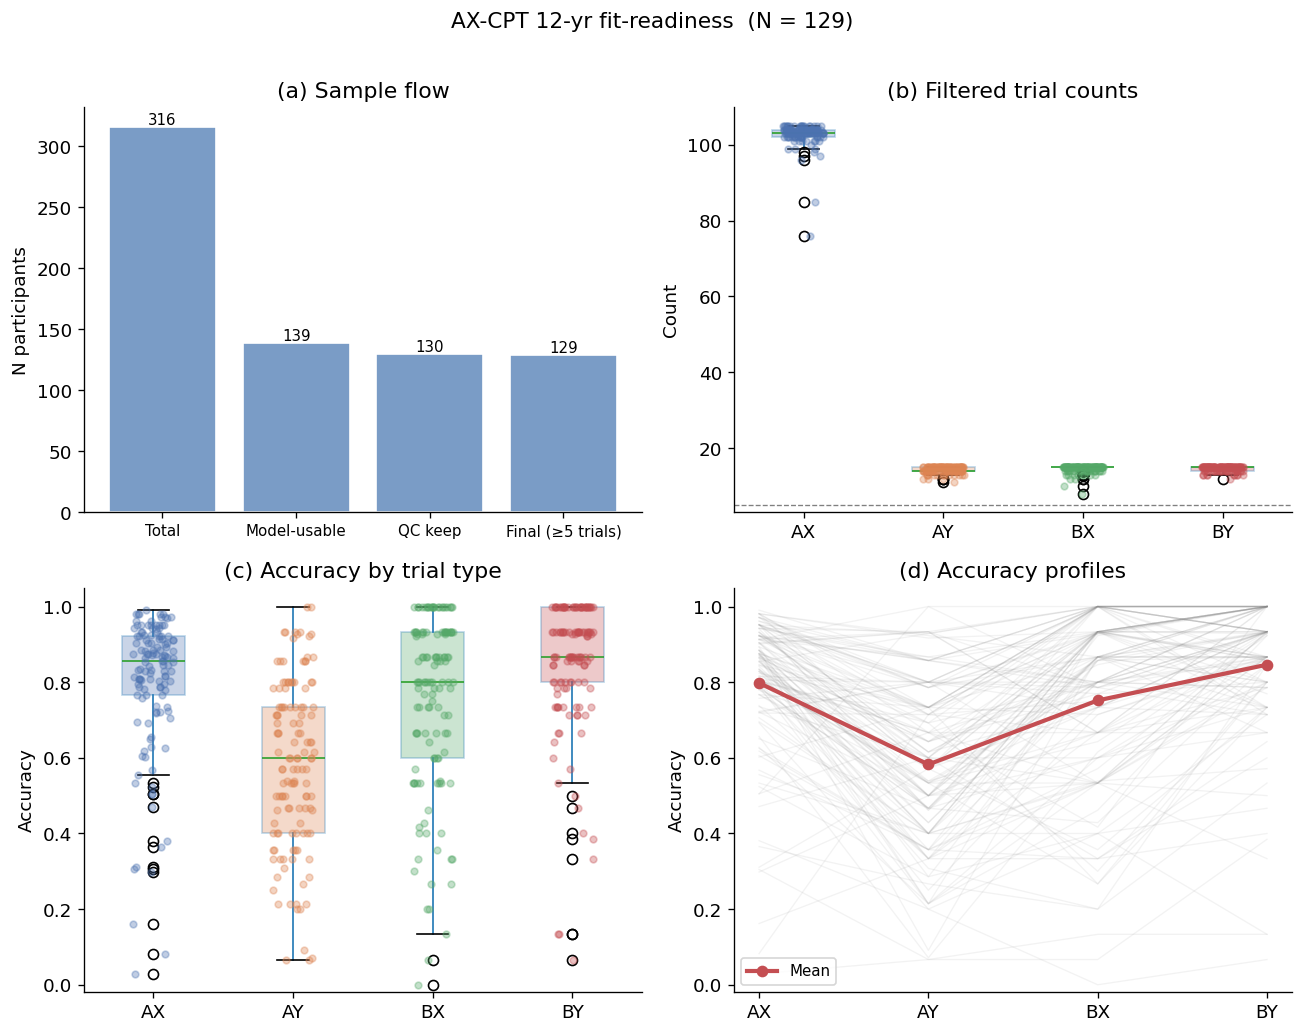

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))

# --- (a) Sample flow ---
ax = axes[0, 0]
bars = ax.bar(range(len(flow)), flow.values, color="#7A9CC6", edgecolor="white")
ax.set_xticks(range(len(flow)))
ax.set_xticklabels(flow.index, fontsize=9)
for b, v in zip(bars, flow.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 2, str(v), ha="center", fontsize=9)
ax.set_ylabel("N participants")
ax.set_title("(a) Sample flow")

# --- (b) Filtered trial counts ---
ax = axes[0, 1]
long_counts = fit_df[count_cols].rename(columns=label_of).melt(var_name="trial_type", value_name="value")
bp = long_counts.boxplot(column="value", by="trial_type", ax=ax, grid=False,
                          patch_artist=True, return_type="dict")
for patch, t in zip(bp["value"]["boxes"], TRIAL_TYPES):
    patch.set_facecolor(COLORS[t])
    patch.set_alpha(0.3)
positions = {t: i+1 for i, t in enumerate(TRIAL_TYPES)}
jitter_strip(ax, long_counts, positions, COLORS)
ax.axhline(5, ls="--", lw=0.8, color="grey", label="min = 5")
ax.set_title("(b) Filtered trial counts")
ax.set_xlabel("")
ax.set_ylabel("Count")
plt.sca(ax); plt.suptitle("")

# --- (c) Accuracy by trial type ---
ax = axes[1, 0]
long_acc = fit_df[acc_rate_cols].rename(columns=label_of).melt(var_name="trial_type", value_name="value")
bp2 = long_acc.boxplot(column="value", by="trial_type", ax=ax, grid=False,
                        patch_artist=True, return_type="dict")
for patch, t in zip(bp2["value"]["boxes"], TRIAL_TYPES):
    patch.set_facecolor(COLORS[t])
    patch.set_alpha(0.3)
jitter_strip(ax, long_acc, positions, COLORS)
ax.set_ylim(-0.02, 1.05)
ax.set_title("(c) Accuracy by trial type")
ax.set_xlabel("")
ax.set_ylabel("Accuracy")
plt.sca(ax); plt.suptitle("")

# --- (d) Participant accuracy profiles ---
ax = axes[1, 1]
acc_matrix = fit_df[acc_rate_cols].to_numpy()
for row in acc_matrix:
    ax.plot(TRIAL_TYPES, row, alpha=0.1, lw=0.8, color="#888888")
ax.plot(TRIAL_TYPES, np.nanmean(acc_matrix, axis=0), lw=2.5, marker="o", color="#C44E52", label="Mean")
ax.set_ylim(-0.02, 1.05)
ax.set_title("(d) Accuracy profiles")
ax.set_ylabel("Accuracy")
ax.legend(fontsize=9)

fig.suptitle(f"AX-CPT 12-yr fit-readiness  (N = {len(fit_df)})", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## Trial-type proportions check

Compare observed filtered proportions to the intended 70/10/10/10 design.
Large deviations could signal differential attrition or filtering artefacts.

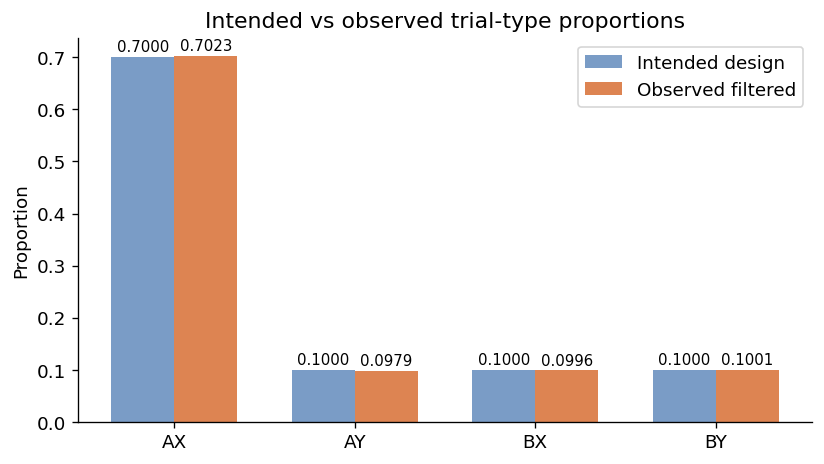

In [16]:
totals = fit_df[count_cols].sum()
obs_prop = totals / totals.sum()
design_prop = pd.Series([0.70, 0.10, 0.10, 0.10], index=TRIAL_TYPES)

comparison = pd.DataFrame({"Design": design_prop, "Observed": obs_prop.values}, index=TRIAL_TYPES)

x = np.arange(4)
w = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, comparison["Design"], w, label="Intended design", color="#7A9CC6")
ax.bar(x + w/2, comparison["Observed"], w, label="Observed filtered", color="#DD8452")
for i in range(4):
    ax.text(i - w/2, comparison["Design"].iloc[i] + 0.01, f"{comparison['Design'].iloc[i]:.4f}", ha="center", fontsize=9)
    ax.text(i + w/2, comparison["Observed"].iloc[i] + 0.01, f"{comparison['Observed'].iloc[i]:.4f}", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(TRIAL_TYPES)
ax.set_ylabel("Proportion")
ax.set_title("Intended vs observed trial-type proportions")
ax.legend()
fig.tight_layout()
plt.show()

## Robustness considerations for binomial fitting

**What this pipeline covers:**

- Complete-case filtering: every participant has all eight binomial cells (4 counts, 4 correct counts).
- QC gate: only experimenter-accepted sessions are retained.
- Sparse-cell exclusion: every cell has ≥ 5 filtered trials, avoiding extreme-proportion artefacts.
- Trial-type proportion sanity check against the intended design.

**What should additionally check:**

- **Ceiling/floor accuracy.** Participants with 0% or 100% accuracy on a trial type produce boundary MLEs (0 or 1) that can distort group-level estimates. Consider whether a continuity correction (e.g. adding 0.5 successes and 0.5 failures) or a Beta-Binomial model is warranted.
- **Overdispersion.** Standard binomial assumes each trial is independent with a fixed *p*. If there is within-person trial-to-trial dependence (e.g. learning, fatigue), the variance is larger than binomial. A Beta-Binomial or quasi-binomial model handles this.
- **Separation / complete separation.** If any predictor perfectly predicts the outcome for a trial type, MLE doesn't converge. Firth-penalised or Bayesian logistic regression avoids this.
- **Unequal trial counts across types.** AX trials vastly outnumber BX/BY. Binomial models weight by *n* automatically, but this means AX dominates the likelihood. Make sure this is intentional, or fit separate models per trial type.
- **Outlier profiles.** The spaghetti plot above flags unusual participants. Consider robust fits or sensitivity analyses excluding extreme profiles.

## Export

In [19]:
export_path = project_root / "data" / "AXCPT_12yr_fitting_sample.csv"
fit_df.to_csv(export_path, index=False)
print(f"Saved {len(fit_df)} participants to {export_path}")

Saved 129 participants to /Users/yizj/Desktop/AX-CPT/metaControl_behavioral_Inhibition/data/AXCPT_12yr_fitting_sample.csv
